In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import bioacoustics_model_zoo as bmz
import csv
import lancedb
import pyarrow as pa
import soundfile as sf
import librosa
import numpy as np
import tempfile
import pandas as pd
import torch
from torch_geometric.data import HeteroData
from collections import defaultdict
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt
import networkx as nx


2025-07-30 16:04:35.802819: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753916676.053515   52457 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753916676.120806   52457 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1753916676.530411   52457 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753916676.530456   52457 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1753916676.530461   52457 computation_placer.cc:177] computation placer alr

In [3]:
# Perch can only generate embeddings for audio files greater than 5 seconds. Therefore, loop any short audio files to make it atleast 5 seconds
def pad_short_clip(audio_path):
    target_duration_sec = 5
    samplerate=sf.info(audio_path).samplerate
    target_len = samplerate * target_duration_sec
    y, sr = librosa.load(audio_path, sr=samplerate)
    #pad if less than 5 seconds
    if len(y) < target_len:
        reps = int(np.ceil(target_len / len(y)))
        y = np.tile(y, reps)[:target_len]
    return np.asarray(y, dtype=np.float32), sr

In [4]:
def generate_embedding(audio_path):
    info = sf.info(audio_path)
    duration = info.frames / info.samplerate #faster than using librosa to load length
    if (duration < 5):
        formatted_wav, sample_rate = pad_short_clip(audio_path)
        #creates a new wav file of 5 seconds long to generate embedding and then immediately deletes it
        with tempfile.NamedTemporaryFile(suffix=".wav", delete=True) as tmp:
            # Write the array to the temp .wav file
            sf.write(tmp.name, formatted_wav, sample_rate)
            # Use the file path for embedding
            embedding = model.embed(tmp.name)
    # if >=5 seconds then embed directly
    else:
        embedding = model.embed(audio_path)
    return embedding, duration

In [5]:
###### STEP 1: PARSE lIKED SOUNDS & COLLECT DATA IN GENERAL #######
#order: 
#   1. parse the csv of liked & generate a hashmap where key is the filename & value is the entire dicitonary that would be the entry to lancedb
#   2. go through ALL wav files in directory & see if its filename matches the filename of the key in the hashmp from step 1. if so, then, insert it as a new column in the value dictionary.
#        -> save path to all wav files in array
#   3. once you have gone through ALL wav files in the direcotry & if any do not have a filepath associated with them, then remove them from the hashmap entirely

# === Step 1: Parse the CSV & build the hashmap ===
csv_file_path = "/home/s.kamboj.400/unzipped-music/mount/Liked Sounds/Location A Sand Forrest/Metadat -  Sandforest.csv"
filename_to_metadata = {}

with open(csv_file_path, newline='', encoding='utf-8') as csvfile:
    reader = csv.DictReader(csvfile, delimiter=';')
    for row in reader:
        filename = row["FileName"]
        filename_to_metadata[filename] = dict(row)
    # After parsing your CSV

#get all columns so that you can create empty frames later on
fieldnames = list(next(iter(filename_to_metadata.values())).keys())
fieldnames.append("FilePath") 
#print(fieldnames)


# === Step 2: Walk through all .wav files and insert filepath ===
root_dir = "/home/s.kamboj.400/unzipped-music/mount/"
matched_filenames = set()
#all_audio_files = []

countInvalid=0
countLessThanFive=0

for dirpath, _, filenames in os.walk(root_dir):
    for name in filenames:
        if name.endswith(".wav"):
            full_path = os.path.join(dirpath, name)
            #makes sure file is not corrupted
            try:
                sf.info(full_path)
            except (RuntimeError, sf.LibsndfileError):
                continue

            # duration_seconds = librosa.get_duration(path=full_path)
            # if (duration_seconds<5):
            #     countLessThanFive+=1
            if name in filename_to_metadata:
                # Case 1: metadata already exists for liked sounds — just add path
                filename_to_metadata[name]["FilePath"] = full_path
                matched_filenames.add(name)
            elif "Liked Sounds" in os.path.normpath(dirpath).split(os.sep):
                # Case 2: in "Liked Sounds" folder but not in the metadata csv filename — add blank metadata (this is because there are some files in liked sounds that are not listed in the metadata csv)
                    # we do still need to give it the metadata frame 
                new_entry = {field: "" for field in fieldnames}
                new_entry["FileName"] = name
                new_entry["FilePath"] = full_path
                filename_to_metadata[name] = new_entry
                #ensures this 
                matched_filenames.add(name)
            #else:
                #not a liked song at all. then, store its path so that you can generate and insert embeddings into lancedb. 
                # use the other audio paths in the frame to generate embeddings for queries
                #UNCOMMENT ALL_AUDIO_FILES TO USE ALL AUDIO FILES IN DTORY
                #all_audio_files.append(str(full_path))
            
                # print(f"This audio file {full_path} is not valid (probably corrupted), so nothing is happening")

# === Step 3: Remove unmatched entries ===
# This will only keep entries that were matched with a .wav file, basically deleted any "liked files" whose audio does not actually exist
filename_to_metadata = {
    fname: metadata
    for fname, metadata in filename_to_metadata.items()
    if fname in matched_filenames
}
# print("len of all audio files is ", len(all_audio_files))
# print("len of all metadata is ", len(filename_to_metadata))
# print(f"There are {countInvalid} invalid files")
# print(f"There are {countLessThanFive} audio recordings less than 5 seconds") #3464 audio recordings less than 5 seconds
#no longer make it a key-value pair. now metadata_list is a list of dictionaries of liked sounds that are ready to be inserted into lancedb
metadata_list = list(filename_to_metadata.values())
metadata_list

[{'FileName': 'SERRA_20250503_153307.wav',
  'Format': '256 16',
  'Note': 'Spaced Out Cicada, Bat in Between',
  'Take': 'Wet to Dry Season',
  'Scene': 'Sand Forrest (Location A)',
  'Project': 'NGS Gorongosa',
  'Category': 'Bats / Cicadas',
  'Library': 'Wet To Dry (May)',
  'Tape': '08 AM - 4PM',
  'Channels': '1',
  'Originator': 'Wildlife Accoustics',
  'Reference': 'Ultrasonic',
  'Description': '',
  'Duration': '0:04',
  'FilePath': '/home/s.kamboj.400/unzipped-music/mount/Location A (Sand Forrest)/LA_Sand_Forrest_ULTRASONIC_03-05-25/SERRA_20250503_153307.wav'},
 {'FileName': 'SERRA_20250503_153021.wav',
  'Format': '256 16',
  'Note': 'Cicada Groove',
  'Take': 'Wet to Dry Season',
  'Scene': 'Sand Forrest (Location A)',
  'Project': 'NGS Gorongosa',
  'Category': 'Bats / Cicadas',
  'Library': 'Wet To Dry (May)',
  'Tape': '08 AM - 4PM',
  'Channels': '1',
  'Originator': 'Wildlife Accoustics',
  'Reference': 'Ultrasonic',
  'Description': '',
  'Duration': '0:07',
  'FileP

In [6]:
df = pd.DataFrame(metadata_list)
df.to_csv('liked-sounds-to-clean.csv', index=False)

In [37]:
# FORMAT DATA FROM LIKED-SOUNDS-CLEAN INTO A GRAPH
#load cleaned liked sounds csv
df = pd.read_csv("/home/s.kamboj.400/pyha-analyzer-2.0/liked-sounds-clean.csv", keep_default_na=False)  # replace with actual path
columns = df.columns.tolist()
audio_nodes = df["FileName"].tolist()
file_paths= df["FilePath"].tolist()
# # Generate vector embeddings of all audios using perch embeddings and insert into lancedb
model=bmz.Perch()

MultilabelAveragePrecision init with num_labels  10932  and average  macro


/home/s.kamboj.400/pyha-analyzer-2.0/.venv/lib/python3.11/site-packages/opensoundscape/ml/cnn.py:599: UserWarning: 
                    This architecture is not listed in opensoundscape.ml.cnn_architectures.ARCH_DICT.
                    It will not be available for loading after saving the model with .save() (unless using pickle=True). 
                    To make it re-loadable, define a function that generates the architecture from arguments: (n_classes, n_channels) 
                    then use opensoundscape.ml.cnn_architectures.register_architecture() to register the generating function.

                    The function can also set the returned object's .constructor_name to the registered string key in ARCH_DICT
                    to avoid this warning and ensure it is reloaded correctly by opensoundscape.ml.load_model().

                    See opensoundscape.ml.cnn_architectures module for examples of constructor functions
                    
  warnings.warn(
/home/s.kambo

In [38]:
#initialize mapping to nodename and id
node_id_maps = defaultdict(dict) 
#keep list of nodes
node_lists = defaultdict(list) 
edge_lists = defaultdict(list)

In [39]:
from autopool.tf import AutoPool1D #use tensorflow version of autopool b/c surfperch on tensorflow
autopool = AutoPool1D(axis=0)  # pool across chunks (axis 0)
audio_embeddings=[]
# Add audio nodes first
for idx, name in enumerate(audio_nodes):
    node_id_maps["audio"][name] = idx #map unique id to audio node name
    node_lists["audio"].append(name) #add name of audio node to the list's audio section
    #call generate vector embedding on currfilepath index and save embedding in array
    try:
        chunky_embedding, _ = generate_embedding(file_paths[idx])
        emb_np = chunky_embedding.to_numpy()
        # If multiple chunks → autopool
        if emb_np.shape[0] > 1:
            print('Trying to autpool')
            print(emb_np.shape)
            emb_input = np.expand_dims(emb_np, axis=0) #need 3 dimensions for autpool to work, based on keras according to its documentaiton
            print("new shape ", emb_input.shape)  
            pooled = autopool(emb_input)  # shape: (1280,)
        else:
            print('No autopooling needed')
            pooled = emb_np[0]  # already a single chunk
        audio_embeddings.append(pooled)
    except Exception as e:
        print(f"Error embedding {file_paths[idx]}: {e}")
        continue

  0%|          | 0/1 [00:00<?, ?it/s]

2025-07-30 16:49:45.953568: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator jax2tf_infer_fn_/assert_equal_1/Assert/AssertGuard/Assert


No autopooling needed


  0%|          | 0/1 [00:00<?, ?it/s]

No autopooling needed


...

Trying to autpool
(117, 1280)
new shape  (1, 117, 1280)


  0%|          | 0/108 [00:00<?, ?it/s]

Trying to autpool
(108, 1280)
new shape  (1, 108, 1280)


  0%|          | 0/126 [00:00<?, ?it/s]

Trying to autpool
(126, 1280)
new shape  (1, 126, 1280)


In [40]:
# --- Step 3: Loop over each column and make edges ---
for col in columns:
    if col == "FileName" or col=="FilePath" or col=="Duration":
        continue
    for idx, row in df.iterrows():
        audio_name = row["FileName"]
        audio_id = node_id_maps["audio"][audio_name]
        
        # Handle multi-values separated by slashes
        raw_vals = str(row[col]).split("/")
        for raw_val in raw_vals:
            val = raw_val.strip()
            if val == "":
                continue

            # Register this node in the bigger list
            if val not in node_id_maps[col]:
                node_id_maps[col][val] = len(node_lists[col])
                node_lists[col].append(val)
            val_id = node_id_maps[col][val]

            # Add edge
            edge_lists[("audio", col, col)].append((audio_id, val_id))

In [41]:
# --- Step 4: Create HeteroData object ---
data = HeteroData()

# Add nodes
for node_type, names in node_lists.items():
    data[node_type].num_nodes = len(names)

# Add edges
for (src_type, rel_type, dst_type), edges in edge_lists.items():
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    data[(src_type, rel_type, dst_type)].edge_index = edge_index

audio_feat_matrix = np.vstack(audio_embeddings)  # (N, 1280)
assert audio_feat_matrix.shape[1] == 1280
#audio_feat_matrix = np.vstack(audio_embeddings)
data["audio"].x = torch.tensor(audio_feat_matrix, dtype=torch.float)

data

HeteroData(
  audio={
    num_nodes=41,
    x=[664, 1280],
  },
  Note={ num_nodes=9 },
  Scene={ num_nodes=1 },
  Category={ num_nodes=4 },
  Month={ num_nodes=1 },
  Season={ num_nodes=1 },
  Time={ num_nodes=2 },
  Reference={ num_nodes=5 },
  (audio, Note, Note)={ edge_index=[2, 19] },
  (audio, Scene, Scene)={ edge_index=[2, 34] },
  (audio, Category, Category)={ edge_index=[2, 39] },
  (audio, Month, Month)={ edge_index=[2, 34] },
  (audio, Season, Season)={ edge_index=[2, 34] },
  (audio, Time, Time)={ edge_index=[2, 34] },
  (audio, Reference, Reference)={ edge_index=[2, 34] }
)

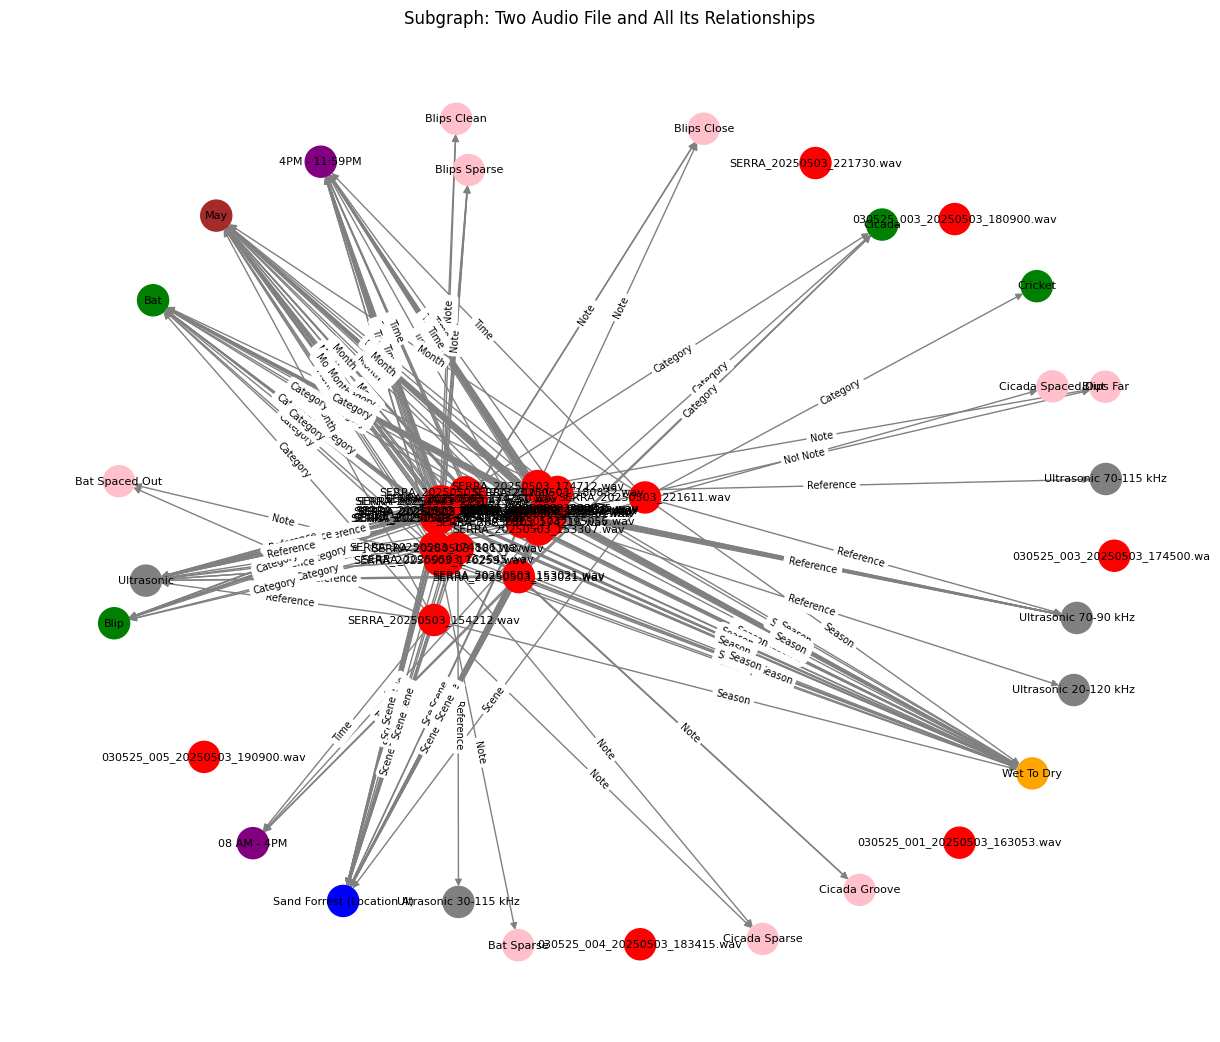

In [42]:
def hetero_to_networkx_subgraph_labeled(data, node_lists, audio_idx_param=0):
    G = nx.MultiDiGraph()
    
    # Helper to get human-readable label
    def get_label(node_type, idx):
        try:
            return node_lists[node_type][idx]
        except IndexError:
            return f"{node_type}_{idx}"
    for i in range(audio_idx_param):
        audio_idx = i
        audio_node = ('audio', audio_idx)
        G.add_node(audio_node, node_type='audio', label=get_label('audio', audio_idx))

        for edge_type in data.edge_types:
            src_type, rel_type, dst_type = edge_type
            edge_index = data[edge_type].edge_index

            for i in range(edge_index.size(1)):
                src = (src_type, int(edge_index[0, i]))
                dst = (dst_type, int(edge_index[1, i]))

                if src == audio_node:
                    G.add_node(dst, node_type=dst_type, label=get_label(dst_type, dst[1]))
                    G.add_edge(src, dst, rel_type=rel_type)
                elif dst == audio_node:
                    G.add_node(src, node_type=src_type, label=get_label(src_type, src[1]))
                    G.add_edge(src, dst, rel_type=rel_type)

    return G

# Create labeled subgraph
#audio_idx_param is number of audio files to include in graph visualization
G_sub = hetero_to_networkx_subgraph_labeled(data, node_lists, audio_idx_param=40)

# Draw with actual labels
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_sub, seed=42)

color_map = []
for node, attrs in G_sub.nodes(data=True):
    ntype = attrs.get("node_type", "unknown")
    color_map.append({
        "audio": "red",
        "Category": "green",
        "Scene": "blue",
        "Season": "orange",
        "Time": "purple",
        "Note": "pink",
        "Reference": "gray",
        "Month": "brown",
        #"": "teal",
        "Tape": "yellow",
    }.get(ntype, "black"))

# Use the human-readable label
labels = {node: data['label'] for node, data in G_sub.nodes(data=True)}

nx.draw(
    G_sub, pos,
    node_color=color_map,
    node_size=500,
    with_labels=True,
    labels=labels,
    font_size=8,
    edge_color='gray',
    arrows=True
)

# Optional: label edge types
edge_labels = {(u, v): d['rel_type'] for u, v, d in G_sub.edges(data=True)}
nx.draw_networkx_edge_labels(G_sub, pos, edge_labels=edge_labels, font_size=7)

plt.title("Subgraph: Two Audio File and All Its Relationships")
plt.axis("off")
plt.show()


In [43]:
print(data)

HeteroData(
  audio={
    num_nodes=41,
    x=[664, 1280],
  },
  Note={ num_nodes=9 },
  Scene={ num_nodes=1 },
  Category={ num_nodes=4 },
  Month={ num_nodes=1 },
  Season={ num_nodes=1 },
  Time={ num_nodes=2 },
  Reference={ num_nodes=5 },
  (audio, Note, Note)={ edge_index=[2, 19] },
  (audio, Scene, Scene)={ edge_index=[2, 34] },
  (audio, Category, Category)={ edge_index=[2, 39] },
  (audio, Month, Month)={ edge_index=[2, 34] },
  (audio, Season, Season)={ edge_index=[2, 34] },
  (audio, Time, Time)={ edge_index=[2, 34] },
  (audio, Reference, Reference)={ edge_index=[2, 34] }
)


In [44]:
data['audio']

{'num_nodes': 41, 'x': tensor([[-0.0848, -0.0558,  0.0316,  ...,  0.0808,  0.0383, -0.0437],
        [-0.0379, -0.1303,  0.0089,  ...,  0.0917,  0.1561, -0.0288],
        [-0.0486, -0.1511,  0.0530,  ..., -0.0016,  0.0971, -0.0212],
        ...,
        [ 0.4655,  0.0942, -0.0156,  ..., -0.0309,  0.0997,  0.0014],
        [ 0.4410,  0.0200,  0.0270,  ..., -0.0442,  0.1218,  0.0186],
        [ 0.3475,  0.0713,  0.0197,  ..., -0.0649,  0.1248,  0.0017]])}

In [45]:
import torch.nn as nn

class FeatureEncoder(nn.Module):
    def __init__(self, data, embed_dim):
        super().__init__()
        self.embeddings = nn.ModuleDict()
        for node_type in data.node_types:
            if 'x' not in data[node_type] or data[node_type].x is None: # if the node type does not have 'x' feature aka does not have embedding yet then give it embedding. does not overwrite what does have an embedding
                num_nodes = data[node_type].num_nodes
                self.embeddings[node_type] = nn.Embedding(num_nodes, embed_dim) #random initialization

    def forward(self, x_dict):
        out = {}
        #x_dict["audio"] has an embedding vector already
        for node_type in data.node_types:
            if node_type in self.embeddings:
                out[node_type] = self.embeddings[node_type].weight
            elif node_type in x_dict:
                out[node_type] = x_dict[node_type]
            else:
                raise KeyError(f"Node type {node_type} not in x_dict or embeddings")
        
        return out
    

In [46]:
from torch_geometric.nn import HGTConv
import torch.nn.functional as F
from torch.nn import Linear, Module
import torch


##TODO : Activation function IE RELU!!!
class HGTEncoder(nn.Module):
    #hidden channels is the dimension of the embedidng vector as it keeps learning
    #num layers is essentially how many "hops" you can take. ie one layer means you cna only go to neighbor but 2 layers means you can go to neighbor's neighbor. dont make it too high then oversmoothing
    # num_heads = number of semantically important node types you want the model to distinguish between. too high of a number is computationally expensive
    def __init__(self, x_dict, metadata, hidden_channels=32, num_heads=4, num_layers=2):
        super().__init__()
        self.metadata = metadata # metadata contains info about all nodes and edges in the graph, as well as the features from previous function. this is built from the heterodata object
        #create dictionary of linear layers for each node type (it is dictionary because each node type cna have different dimension)
        self.input_lin = nn.ModuleDict()
        #store all layers and update features in a list 
        self.convs = nn.ModuleList()

        #get all different node types 
        for node_type in metadata[0]:
            if node_type not in x_dict:
                raise ValueError(f"{node_type} not in x_dict!")
            in_dim = x_dict[node_type].size(1)
            self.input_lin[node_type] = nn.Linear(in_dim, hidden_channels)


        for _ in range(num_layers):
            self.convs.append(HGTConv(
                in_channels=hidden_channels,
                out_channels=hidden_channels,
                metadata=metadata,
                heads=num_heads
            ))

    #x dict is result of feature encoder, which contains embeddings for all node types
    #edge_index_dict is a dictionary of edge indices for each edge type, which is used to define the connections between nodes in the graph
    def forward(self, x_dict, edge_index_dict):
        # print("x_dict before input_lin:")
        # for k, v in x_dict.items():
        #     print(f"{k}: shape = {v.shape}")
            
        #standardize all node features to the same dimension from self.input_lin[node_type] in the init function
        x_dict = {
            node_type: self.input_lin[node_type](x)
            for node_type, x in x_dict.items()
        }
        # print("x_dict after input_lin:")
        # for k, v in x_dict.items():
        #     print(f"{k}: shape = {v.shape}")
            
        #looks up neighbor that node has, applies attention to it & updates node features in x_dict itself
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict)
        
        
        #contians final rep of each node type after all layers. THIS is input for link predictor
        return x_dict
    


In [47]:
# class GeneralLinkPredictor(nn.Module):
#     def __init__(self, hidden_channels, metadata):
#         super().__init__()
#         self.metadata = metadata
#         self.link_scorers = nn.ModuleDict()

#         for (src_type, rel_type, dst_type) in metadata[1]:  # edge types
#             self.link_scorers[f"{src_type}_{rel_type}_{dst_type}"] = nn.Sequential(
#                 nn.Linear(hidden_channels * 2, hidden_channels),
#                 nn.ReLU(),
#                 nn.Linear(hidden_channels, 1)
#             )

#     def forward(self, embeddings, edge_index_dict):
#         predictions = {}
#         for (src_type, rel_type, dst_type), edge_index in edge_index_dict.items():
#             h_src = embeddings[src_type][edge_index[0]]
#             h_dst = embeddings[dst_type][edge_index[1]]
#             h_cat = torch.cat([h_src, h_dst], dim=-1)
#             key = f"{src_type}_{rel_type}_{dst_type}"
#             score = self.link_scorers[key](h_cat).squeeze(-1)
#             predictions[(src_type, rel_type, dst_type)] = score
#         return predictions

class LinkPredictor(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        #MLP that predicts whether 2 nodes should be connected. can learn non-linear relationships
        self.lin = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x_src, x_dst):
        return self.lin(torch.cat([x_src, x_dst], dim=-1)).view(-1)


In [48]:
from torch_geometric.transforms import ToUndirected
from torch_geometric.utils import negative_sampling
#add reverse edges everywhere. makes audio a destination node as well so that HGTConv does not error
data = ToUndirected()(data)

feature_encoder = FeatureEncoder(data, embed_dim=32) # make sure that the non-audio nodes also have embeddings. Make it same embedding dimesntion as audio nodes
x_dict = feature_encoder(data.x_dict)  # ensures all node types have embeddings
#print(x_dict['Note'])

# print("x_dict keys:", list(x_dict.keys()))

metadata = data.metadata()  # (node_types, edge_types)
encoder = HGTEncoder(x_dict, metadata, hidden_channels=32, num_heads=4, num_layers=2)

# print(data.metadata())
# for edge_type, edge_index in data.edge_index_dict.items():
#     print(f"{edge_type}: {edge_index.size(1)} edges")

# print("metadata node types:", data.metadata()[0])
# print("edge_index_dict keys:", list(data.edge_index_dict.keys()))
# print(data.edge_index_dict)
x_out = encoder(x_dict, data.edge_index_dict)

link_predictor = LinkPredictor(hidden_dim=32)

#update all the weights in both the encoder (for ndoe represenations & inference in the future) and the link predictor 
optimizer = torch.optim.Adam(
    list(encoder.parameters()) + list(link_predictor.parameters()), lr=0.005
)
#use this as loss function because it is a "binary" classifier of whether link exists or not
loss_fn = torch.nn.BCEWithLogitsLoss()
num_epochs = 60

#implements negative sampling : generate edges that do not exist so that model can distinguish between actual connecitons and non-connections
for epoch in range(num_epochs):
    encoder.train()
    link_predictor.train()
    x_dict = feature_encoder(data.x_dict) #gets node layers and initial embeddings
    x_out = encoder(x_dict, data.edge_index_dict) #applies HGT layers to get updated node embeddings

    total_loss = 0.0

    #loop over all edge types to look @ all possible relations (ie ('audio', 'Note', 'Note'))
    for edge_type in data.edge_types:
        src_type, _, dst_type = edge_type
        #edge_index = torch.tensor([ [0, 1, 2],   # source node indices [1, 0, 3]    # target node indices])
        #this means that there is edge from node 0 to 1, node 1 to 0, and node 2 to 3. this is much better than adjacency matrix for storing edges
        edge_index = data[edge_type].edge_index
        #print(f"edge_index is {edge_index}")
        if edge_index.size(1) == 0:
            continue  # skip if no edges
        # Positive examples
        pos_src = edge_index[0]
        pos_dst = edge_index[1]


        # Negative examples -> create fake nodes with fake connections so that model can learn to distingush between 
        neg_edge_index = negative_sampling(
            edge_index=edge_index,
            num_nodes=(data[src_type].num_nodes, data[dst_type].num_nodes),
            num_neg_samples=pos_src.size(0), #have the same number of negative edges as positive edges
            method='sparse' #tends to be more efficient for larger graphs. slow for lookup to see if edge exists but better for scalability, computation, and memory
        )
        neg_src = neg_edge_index[0]
        neg_dst = neg_edge_index[1]

        # Predictions
        pos_pred = link_predictor(x_out[src_type][pos_src], x_out[dst_type][pos_dst]) #better if closer to 1
        neg_pred = link_predictor(x_out[src_type][neg_src], x_out[dst_type][neg_dst]) #better if closer to 0

        # Loss
        pos_loss = loss_fn(pos_pred, torch.ones_like(pos_pred))
        neg_loss = loss_fn(neg_pred, torch.zeros_like(neg_pred))
        total_loss += pos_loss + neg_loss

    total_loss.backward()
    optimizer.step() #updates weights in both encoder and link_predictor
    optimizer.zero_grad()

    print(f"Epoch {epoch+1} | Loss: {total_loss.item():.4f}")

Epoch 1 | Loss: 19.4744
Epoch 2 | Loss: 19.3630
Epoch 3 | Loss: 19.2273
Epoch 4 | Loss: 19.0224
Epoch 5 | Loss: 18.7442
Epoch 6 | Loss: 18.3091
Epoch 7 | Loss: 17.7443
Epoch 8 | Loss: 17.0507
Epoch 9 | Loss: 15.9510
Epoch 10 | Loss: 15.2819
Epoch 11 | Loss: 13.7816
Epoch 12 | Loss: 12.2898
Epoch 13 | Loss: 10.9236
Epoch 14 | Loss: 10.0236
Epoch 15 | Loss: 8.9663
Epoch 16 | Loss: 8.6701
Epoch 17 | Loss: 7.6785
Epoch 18 | Loss: 8.5780
Epoch 19 | Loss: 10.5827
Epoch 20 | Loss: 7.0955
Epoch 21 | Loss: 7.6878
Epoch 22 | Loss: 7.9466
Epoch 23 | Loss: 7.3963
Epoch 24 | Loss: 7.0908
Epoch 25 | Loss: 7.1937
Epoch 26 | Loss: 6.6826
Epoch 27 | Loss: 6.6667
Epoch 28 | Loss: 7.1132
Epoch 29 | Loss: 6.9234
Epoch 30 | Loss: 6.8519
Epoch 31 | Loss: 6.9634
Epoch 32 | Loss: 7.3262
Epoch 33 | Loss: 7.3762
Epoch 34 | Loss: 6.8688
Epoch 35 | Loss: 6.9371
Epoch 36 | Loss: 6.5097
Epoch 37 | Loss: 6.4018
Epoch 38 | Loss: 6.7831
Epoch 39 | Loss: 6.5116
Epoch 40 | Loss: 6.5987
Epoch 41 | Loss: 6.7360
Epoch 42 |

In [52]:
def predict_links_all_edge_types(encoder, link_predictor, data, feature_encoder, k=1):
    encoder.eval()
    link_predictor.eval()

    with torch.no_grad():
        x_dict = feature_encoder(data.x_dict)
        x_out = encoder(x_dict, data.edge_index_dict)

        for edge_type in data.edge_types:
            src_type, _, dst_type = edge_type
            num_src = data[src_type].num_nodes
            num_dst = data[dst_type].num_nodes

            print(f"\n Top {k} predicted links for edge type {edge_type}:")

            # Generate all possible (src, dst) pairs
            src_ids = torch.arange(num_src)
            dst_ids = torch.arange(num_dst)
            src_grid, dst_grid = torch.meshgrid(src_ids, dst_ids, indexing='ij')

            src_flat = src_grid.flatten()
            dst_flat = dst_grid.flatten()

            # Get predictions
            preds = link_predictor(x_out[src_type][src_flat], x_out[dst_type][dst_flat])

            # Top-k
            topk_scores, topk_indices = torch.topk(preds, k=min(k, len(preds)))
            topk_src = src_flat[topk_indices]
            topk_dst = dst_flat[topk_indices]

            # Print results
            for s, d, score in zip(topk_src.tolist(), topk_dst.tolist(), topk_scores.tolist()):
                #print(f"  {src_type}[{s}] -> {dst_type}[{d}] | Score: {score:.4f}")
                print(f"  {node_lists[src_type][s]} -> {node_lists[dst_type][d]} | Probability: {torch.sigmoid(torch.tensor(score)).item()}")



In [53]:
predict_links_all_edge_types(
    encoder=encoder,
    link_predictor=link_predictor,
    data=data,
    feature_encoder=feature_encoder,
    k=1
)



 Top 1 predicted links for edge type ('audio', 'Note', 'Note'):
  SERRA_20250503_153307.wav -> Blips Sparse | Probability: 0.9286810755729675

 Top 1 predicted links for edge type ('audio', 'Scene', 'Scene'):
  SERRA_20250503_153307.wav -> Sand Forrest (Location A) | Probability: 0.9999575614929199

 Top 1 predicted links for edge type ('audio', 'Category', 'Category'):
  SERRA_20250503_153307.wav -> Bat | Probability: 0.9604623317718506

 Top 1 predicted links for edge type ('audio', 'Month', 'Month'):
  SERRA_20250503_153307.wav -> May | Probability: 0.9998445510864258

 Top 1 predicted links for edge type ('audio', 'Season', 'Season'):
  SERRA_20250503_153307.wav -> Wet To Dry | Probability: 0.9998041987419128

 Top 1 predicted links for edge type ('audio', 'Time', 'Time'):
  SERRA_20250503_153307.wav -> 4PM - 11:59PM | Probability: 0.9794253706932068

 Top 1 predicted links for edge type ('audio', 'Reference', 'Reference'):
  SERRA_20250503_153307.wav -> Ultrasonic | Probability: 

In [ ]:
####### STEP 2: insert vector embeddings of all sounds into lancedb #######
#Insert data into lancedb
count=0
records_to_insert=[]
batch_size_to_insert=100
# countOfLessThan5=0
for curr_wav_file in all_audio_files:
    #return embedding & duration so you can determine if looped or not
    embedding, duration= generate_embedding(curr_wav_file)

    #loop through all chunks of 5 second recordings for current wav file and insert into lancedb
    for i in range(embedding.shape[0]):
        embedding = np.array(embedding) # forces len of embedding to be 1280 by not letting embedding change dimensions
        start_sec = i * 5
        end_sec = (i + 1) * 5
        duration_str = f"{start_sec}-{end_sec}"
        metadata = {
            "FileName": os.path.basename(curr_wav_file),
            "Format": "",         
            "Note": "",
            "Take": "",
            "Scene": "",
            "Project": "",
            "Category": "",
            "Library": "",
            "Tape": "",
            "Channels": "",
            "Originator": "",
            "Reference": "",
            "Description": "",
            "Duration": duration_str,
            "FilePath": curr_wav_file,
            "Looped": duration < 5,
            "vector_embedding": embedding[i].tolist(),  
        }
        records_to_insert.append(metadata)
        #fast batching for lancedb insertion & memory safe
        if len(records_to_insert) >= batch_size_to_insert:
            table.add(records_to_insert)
            records_to_insert.clear()
    # count+=1
    # if (count>=5000):
    #     break
#insert any remaining records
if records_to_insert:
    table.add(records_to_insert)

In [ ]:
#check stuff was inserted
df = table.to_pandas()
print(df.head())  # Show first 5 rows

In [ ]:
###### STEP 3 : Generate vector embeddings of liked sounds and generate similarity search of liked sounds #######
#loop through liked sounds & generate vector embeddings
from IPython.display import Audio, display
count=0
for currLikedDict in metadata_list:
    audio_path= currLikedDict["FilePath"]
    embedding, _= generate_embedding(audio_path)
    for i in range(embedding.shape[0]):
        embedding = np.array(embedding)
        query_vector = embedding[i].tolist()
        #search lancedb with those vector embeddings
        results = table.search(query_vector).limit(1).to_pandas()
        print("The most similar to ", audio_path, " chunk #", (i+1), " is", results["FilePath"].tolist()[0])
        print("Liked audio:")
        display(Audio(audio_path))
        matched_path = results["FilePath"].tolist()[0]
        matched_duration = results["Duration"].tolist()[0]
        # Parse "start-end" from Duration field
        start_sec, end_sec = map(int, matched_duration.split('-'))
        duration = end_sec - start_sec

        # Load just the 5-second chunk (efficient)
        y, sr = librosa.load(matched_path, sr=None, offset=start_sec, duration=duration)

        # Display the audio player
        print("Most similar 5-second chunk from time :", matched_duration)
        display(Audio(y, rate=sr))

    # count+=1
    # if (count>5):
    #     break
